# AI CSPM Overwatch

## Оцінювані метрики
У цьому ноутбуці обчислюються та візуалізуються наступні ключові показники для інструментів **Prowler** та **AWS Security Hub**:

1. **Adjustment Rate (%)**: Відсоток знахідок CSPM, для яких LLM змінила критичність або позначила їх як False Positive.
2. **Decision Consistency (%)**: Стабільність рішень моделі. Показує, наскільки часто модель для однієї і тієї ж знахідки (в різних запусках) повертає ідентичну оцінку: ту саму фінальну критичність, той самий статус False Positive та ту саму причину виправлення (Adjustment Category).
3. **Ефективність та вартість**: Залежність між розміром контексту (вхідні токени), згенерованим виводом (вихідні токени) та швидкістю прийняття рішень (Latency) кожною моделлю.

## Математичний апарат та обґрунтування метрик

### 1. Adjustment Rate (Рівень коригувань)
Рівень коригувань відображає схильність моделі до зміни вихідних результатів CSPM. Формула:
$$ AdjustmentRate = \frac{N_{adjusted}}{N_{total}} \times 100\% $$
- $N_{adjusted}$: Кількість знахідок, для яких LLM прийняла рішення про зміну (було змінено критичність, або знахідку позначено як False Positive).
- $N_{total}$: Загальна кількість проаналізованих знахідок.

### 2. Decision Consistency (Стабільність рішень)
Стабільність рішень (детермінованість) вимірює здатність моделі видавати ідентичні рішення для однакових знахідок у різних ітераціях. Формула:
$$ DecisionConsistency = \frac{\sum_{i=1}^{U} I(|D_i| = 1)}{U} \times 100\% $$
- $U$: Загальна кількість унікальних знахідок (комбінація `Finding ID` + `Resource ID`).
- $D_i$: Множина унікальних рішень моделі для $i$-тої знахідки серед усіх ітерацій (запусків). Рішення визначається як кортеж із трьох атрибутів: `(adjusted_severity, is_false_positive, adjustment_category)`. Якщо модель завжди відповідає однаково, розмір цієї множини $|D_i| = 1$.
- $I(|D_i| = 1)$: Функція-індикатор, яка дорівнює 1, якщо рішення для знахідки повністю стабільне у всіх ітераціях, і 0, якщо модель хоча б раз змінила свою думку (тоді $|D_i| > 1$).

### Обґрунтування підходу
У сфері Cloud Security Posture Management (CSPM) ключовими є не лише здатність системи знайти "false positive" (хибне спрацювання), але й **передбачуваність (детермінованість)** цього процесу. 

Якщо модель має високий *Adjustment Rate*, але низький *Decision Consistency*, це вказує на так зване явище «галюцинацій» — модель робить кардинальні зміни, але не може їх стабільно повторити. Такий інструмент не можна впроваджувати у production-середовище, оскільки він створюватиме додатковий "шум" для інженерів замість того, щоб автоматизувати рутину. 

Саме тому *Decision Consistency* обрана як головний критерій якості моделі. Тільки моделі, що стабільно проходять поріг у **80%**, можуть вважатись достатньо зрілими для використання в ролі автоматизованих AI-аудиторів.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import json
import os

# 1. Load Data
if not os.path.exists("../output/analysis/.current_scenario"):
    raise ValueError("No scenario configured. Run pipeline/main.py to set the scenario.")

with open("../output/analysis/.current_scenario", "r") as f:
    scenario_name = f.read().strip()

metrics_path = f"../output/analysis/{scenario_name}/metrics_history.csv"
findings_path = f"../output/analysis/{scenario_name}/findings_history.csv"

if os.path.exists(metrics_path) and os.path.exists(findings_path):
    metrics_df = pd.read_csv(metrics_path)
    findings_df = pd.read_csv(findings_path)
    metrics_df = metrics_df.fillna(0)
    findings_df = findings_df.fillna("")
else:
    print(f"CSV files not found for scenario {scenario_name}.")
    metrics_df = pd.DataFrame()
    findings_df = pd.DataFrame()

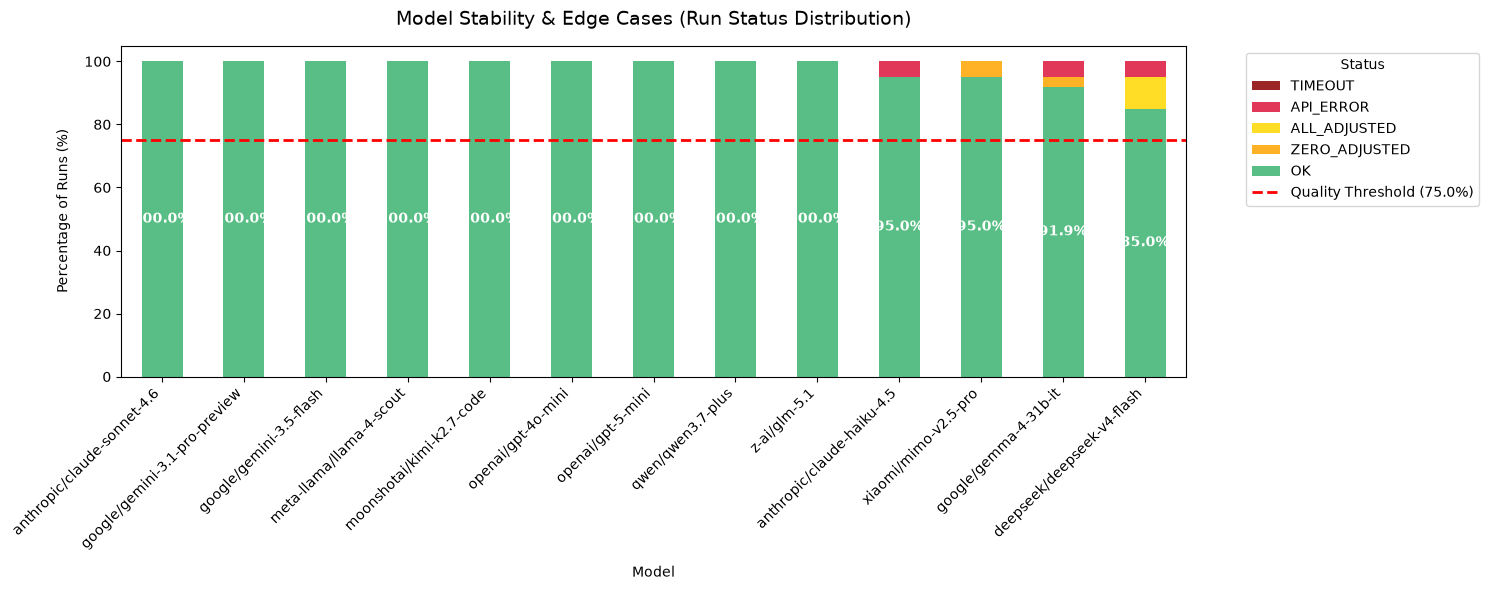


--- Quality Filter ---
Models passing >=75.0% Quality Rate: ['anthropic/claude-sonnet-4.6', 'google/gemini-3.1-pro-preview', 'google/gemini-3.5-flash', 'meta-llama/llama-4-scout', 'moonshotai/kimi-k2.7-code', 'openai/gpt-4o-mini', 'openai/gpt-5-mini', 'qwen/qwen3.7-plus', 'z-ai/glm-5.1', 'anthropic/claude-haiku-4.5', 'xiaomi/mimo-v2.5-pro', 'google/gemma-4-31b-it', 'deepseek/deepseek-v4-flash']
Models filtered out: []



In [2]:
if not metrics_df.empty and 'error_type' in metrics_df.columns:
    # 1. Prepare data for stacked bar chart
    status_df = metrics_df.groupby(['model', 'error_type']).size().unstack(fill_value=0)
    
    # Rename 'NONE' to 'OK'
    if 'NONE' in status_df.columns:
        status_df.rename(columns={'NONE': 'OK'}, inplace=True)
        
    # Ensure all expected columns exist
    for col in ['OK', 'ZERO_ADJUSTED', 'ALL_ADJUSTED', 'API_ERROR', 'TIMEOUT']:
        if col not in status_df.columns:
            status_df[col] = 0
            
    # Calculate Quality Rate (Success Rate)
    status_df['Total'] = status_df.sum(axis=1)
    status_df['Quality_Rate'] = (status_df['OK'] / status_df['Total']) * 100
    
    # Sort by Quality Rate descending
    status_df = status_df.sort_values(by='Quality_Rate', ascending=False)
    
    # Convert absolute counts to percentages for the stacked bar
    plot_cols = ['OK', 'ZERO_ADJUSTED', 'ALL_ADJUSTED', 'API_ERROR', 'TIMEOUT']
    percent_df = status_df[plot_cols].div(status_df['Total'], axis=0) * 100
    
    # Plotting
    colors = {
        'OK': 'mediumseagreen',
        'ZERO_ADJUSTED': 'orange',
        'ALL_ADJUSTED': 'gold',
        'API_ERROR': 'crimson',
        'TIMEOUT': 'darkred'
    }
    
    fig, ax = plt.subplots(figsize=(15, 6))
    
    percent_df.plot(kind='bar', stacked=True, color=[colors[c] for c in plot_cols], ax=ax, alpha=0.85)
    
    # Add Threshold Line
    threshold = 75.0
    ax.axhline(y=threshold, color='red', linestyle='--', linewidth=2, label=f'Quality Threshold ({threshold}%)')
    
    ax.set_title("Model Stability & Edge Cases (Run Status Distribution)", fontsize=14, pad=15)
    ax.set_xlabel("Model", labelpad=10)
    ax.set_ylabel("Percentage of Runs (%)", labelpad=10)
    ax.set_ylim(0, 105)
    
    # Add percentage labels on the 'OK' bars for clarity
    for i, model in enumerate(percent_df.index):
        ok_pct = percent_df.loc[model, 'OK']
        if ok_pct > 5:  # Only label if there's enough space
            ax.text(i, ok_pct / 2, f'{ok_pct:.1f}%', ha='center', va='center', color='white', fontweight='bold')
    
    # Adjust legend
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[::-1], labels[::-1], title="Status", bbox_to_anchor=(1.05, 1), loc='upper left')
    
    for tick in ax.get_xticklabels():
        tick.set_rotation(45)
        tick.set_ha('right')
        
    fig.tight_layout()
    plt.show()

    # --- FILTERING ---
    # Keep only models that passed the threshold
    passed_models = status_df[status_df['Quality_Rate'] >= threshold].index.tolist()
    
    print(f"\n--- Quality Filter ---")
    print(f"Models passing >={threshold}% Quality Rate: {passed_models}")
    print(f"Models filtered out: {list(set(status_df.index) - set(passed_models))}\n")
    
    # Filter the global dataframes so all subsequent charts only show passed models
    metrics_df = metrics_df[metrics_df['model'].isin(passed_models)]
    if not findings_df.empty:
        findings_df = findings_df[findings_df['model'].isin(passed_models)]
    # Filter out runs that did not succeed so they don't corrupt subsequent metrics (like consistency)
    metrics_df = metrics_df[(metrics_df['error_type'] == 'NONE') & (metrics_df['parsing_success'] == True)]
    if not findings_df.empty:
        valid_keys = set(zip(metrics_df['run_id'], metrics_df['cspm_tool']))
        findings_df = findings_df[findings_df.apply(lambda row: (row['run_id'], row['cspm_tool']) in valid_keys, axis=1)]


In [3]:
def calculate_summary(m_df, f_df):
    summary = {}
    
    if m_df.empty or f_df.empty:
        return summary
        
    f_df = f_df.copy()
    f_df['decision_signature'] = f_df['adjusted_severity'].astype(str) + "_" + f_df['is_false_positive'].astype(str) + "_" + f_df['adjustment_category'].astype(str)
    
    tools = m_df['cspm_tool'].unique()
    
    for tool in tools:
        t_m = m_df[m_df['cspm_tool'] == tool]
        t_f = f_df[f_df['cspm_tool'] == tool]
        
        summary[tool] = {"models_summary": []}
        
        models = t_m['model'].unique()
        for model in models:
            mod_m = t_m[t_m['model'] == model]
            mod_f = t_f[t_f['model'] == model]
            
            # KPI values
            adj_rate = mod_m['adjustment_rate_percentage'].mean()
            latency = mod_m['latency_seconds'].mean()
            total_tokens = mod_m['prompt_tokens'].mean() + mod_m['completion_tokens'].mean()
            
            # Consistency
            if len(mod_m) > 1:
                cons_df = mod_f.groupby(['finding_id', 'resource_id'])['decision_signature'].nunique()
                cons_rate = (cons_df == 1).mean() * 100
            else:
                cons_rate = None
                
            # Adjustment Categories
            is_fp = mod_f["is_false_positive"].astype(str).str.lower() == "true"
            adjusted = mod_f[(mod_f["adjusted_severity"] != mod_f["original_severity"]) | is_fp]
            
            cat_counts = {}
            if not adjusted.empty:
                cats = adjusted["adjustment_category"].value_counts()
                for c_name, c_count in cats.items():
                    if c_name and c_name != "NONE":
                        cat_counts[c_name] = int(c_count)
                        
            summary[tool]["models_summary"].append({
                "model": model.replace("local/", "").split("/")[-1],
                "adjustment_rate": round(adj_rate, 2),
                "decision_consistency": round(cons_rate, 2) if cons_rate is not None else None,
                "latency": round(latency, 2),
                "total_tokens": int(total_tokens),
                "adjustment_categories": cat_counts
            })
            
    return summary

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Налаштування стилю графіків
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

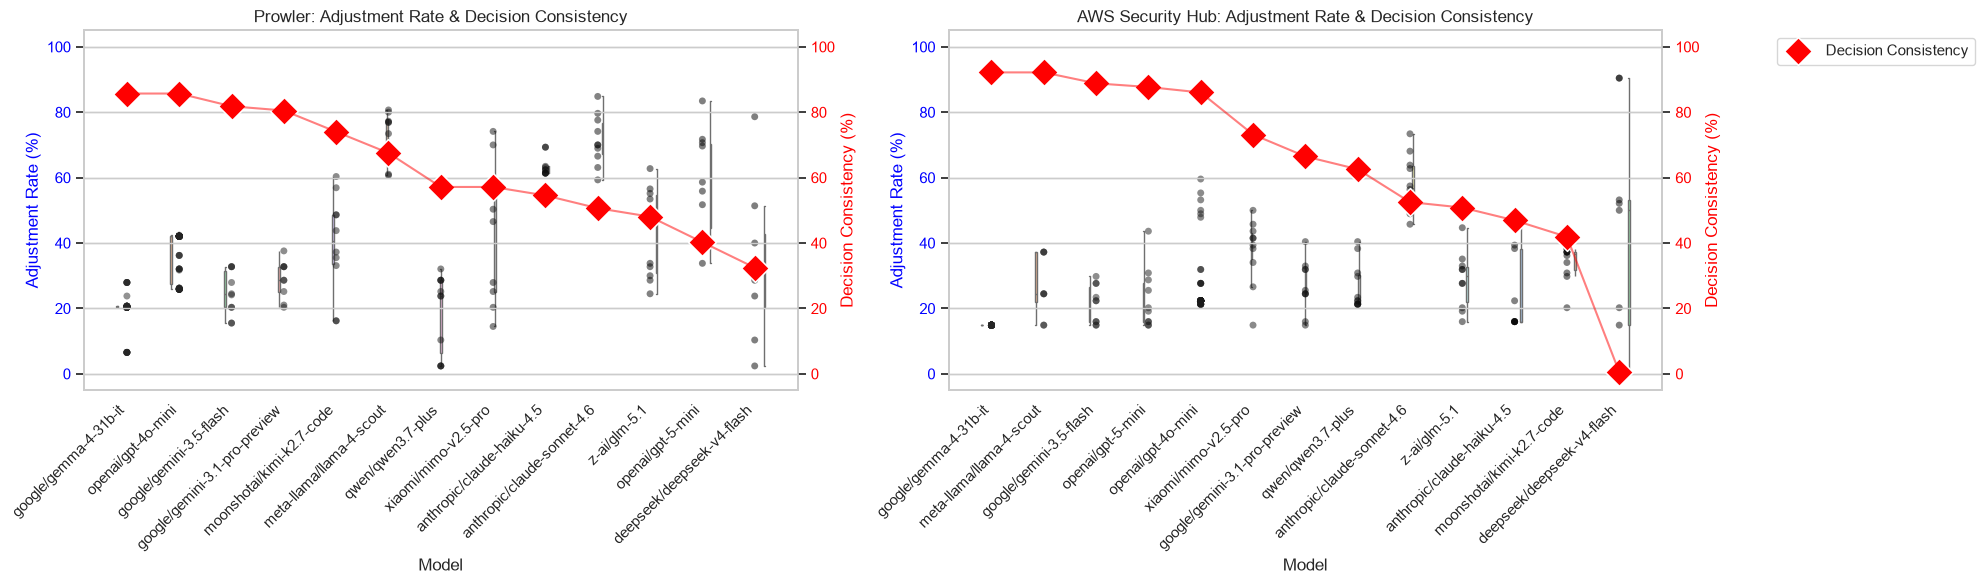

In [5]:
def prep_consistency_data(m_df, f_df):
    if m_df.empty or f_df.empty:
        return pd.DataFrame(), pd.DataFrame()
    f_df = f_df.copy()
    f_df['decision_signature'] = f_df['adjusted_severity'].astype(str) + "_" + f_df['is_false_positive'].astype(str) + "_" + f_df['adjustment_category'].astype(str)
    
    runs_per_model = m_df.groupby('model')['run_id'].nunique()
    
    consistency_df = f_df.groupby(['model', 'finding_id', 'resource_id'])['decision_signature'].nunique().reset_index()
    consistency_df['is_consistent'] = consistency_df['decision_signature'] == 1
    
    model_consistency = consistency_df.groupby('model')['is_consistent'].mean().reset_index()
    model_consistency.rename(columns={'is_consistent': 'consistency_rate'}, inplace=True)
    model_consistency['consistency_rate'] *= 100
    
    # Nullify consistency if only 1 run
    model_consistency['consistency_rate'] = model_consistency.apply(
        lambda row: row['consistency_rate'] if runs_per_model.get(row['model'], 0) > 1 else np.nan, 
        axis=1
    )
    
    # Sort by consistency rate descending
    model_consistency = model_consistency.sort_values(by='consistency_rate', ascending=False, na_position='last')
    
    run_adjustments = m_df[['run_id', 'model', 'adjustment_rate_percentage']].copy()
    run_adjustments['model'] = pd.Categorical(run_adjustments['model'], categories=model_consistency['model'], ordered=True)
    run_adjustments = run_adjustments.sort_values('model')
    
    return run_adjustments, model_consistency

if not metrics_df.empty:
    p_m = metrics_df[metrics_df['cspm_tool'].str.lower() == 'prowler']
    p_f = findings_df[findings_df['cspm_tool'].str.lower() == 'prowler']
    s_m = metrics_df[metrics_df['cspm_tool'].str.lower() == 'securityhub']
    s_f = findings_df[findings_df['cspm_tool'].str.lower() == 'securityhub']
    
    p_run, p_cons = prep_consistency_data(p_m, p_f)
    s_run, s_cons = prep_consistency_data(s_m, s_f)
    
    fig, (ax_p, ax_s) = plt.subplots(1, 2, figsize=(20, 6))
    
    # --- Prowler ---
    if not p_run.empty:
        sns.boxplot(data=p_run, x='model', y='adjustment_rate_percentage', ax=ax_p, hue='model', legend=False, palette='pastel', showfliers=False, width=0.4)
        sns.stripplot(data=p_run, x='model', y='adjustment_rate_percentage', ax=ax_p, palette='dark:black', alpha=0.5, jitter=False, hue='model', legend=False)
        ax_p.set_xlabel('Model')
        ax_p.set_ylabel('Adjustment Rate (%)', color='blue')
        ax_p.tick_params(axis='y', labelcolor='blue')
        ax_p.set_ylim(-5, 105)
        ax_p2 = ax_p.twinx()
        sns.scatterplot(data=p_cons, x='model', y='consistency_rate', ax=ax_p2, color='red', s=200, marker='D')
        
        # Draw lineplot only connecting non-NaN values
        valid_p_cons = p_cons.dropna(subset=['consistency_rate'])
        if not valid_p_cons.empty:
            sns.lineplot(data=valid_p_cons, x='model', y='consistency_rate', ax=ax_p2, color='red', alpha=0.5, sort=False)
            
        ax_p2.set_ylabel('Decision Consistency (%)', color='red')
        ax_p2.tick_params(axis='y', labelcolor='red')
        ax_p2.set_ylim(-5, 105)
        ax_p.set_title("Prowler: Adjustment Rate & Decision Consistency")
        for tick in ax_p.get_xticklabels():
            tick.set_rotation(45)
            tick.set_ha('right')
            
    # --- Security Hub ---
    if not s_run.empty:
        sns.boxplot(data=s_run, x='model', y='adjustment_rate_percentage', ax=ax_s, hue='model', legend=False, palette='pastel', showfliers=False, width=0.4)
        sns.stripplot(data=s_run, x='model', y='adjustment_rate_percentage', ax=ax_s, palette='dark:black', alpha=0.5, jitter=False, hue='model', legend=False)
        ax_s.set_xlabel('Model')
        ax_s.set_ylabel('Adjustment Rate (%)', color='blue')
        ax_s.tick_params(axis='y', labelcolor='blue')
        ax_s.set_ylim(-5, 105)
        ax_s2 = ax_s.twinx()
        sns.scatterplot(data=s_cons, x='model', y='consistency_rate', ax=ax_s2, color='red', s=200, marker='D', label='Decision Consistency')
        
        valid_s_cons = s_cons.dropna(subset=['consistency_rate'])
        if not valid_s_cons.empty:
            sns.lineplot(data=valid_s_cons, x='model', y='consistency_rate', ax=ax_s2, color='red', alpha=0.5, sort=False)
            
        ax_s2.set_ylabel('Decision Consistency (%)', color='red')
        ax_s2.tick_params(axis='y', labelcolor='red')
        ax_s2.set_ylim(-5, 105)
        ax_s.set_title("AWS Security Hub: Adjustment Rate & Decision Consistency")
        for tick in ax_s.get_xticklabels():
            tick.set_rotation(45)
            tick.set_ha('right')
        
        ax_s2.legend(bbox_to_anchor=(1.15, 1), loc='upper left')

    fig.tight_layout()
plt.show()

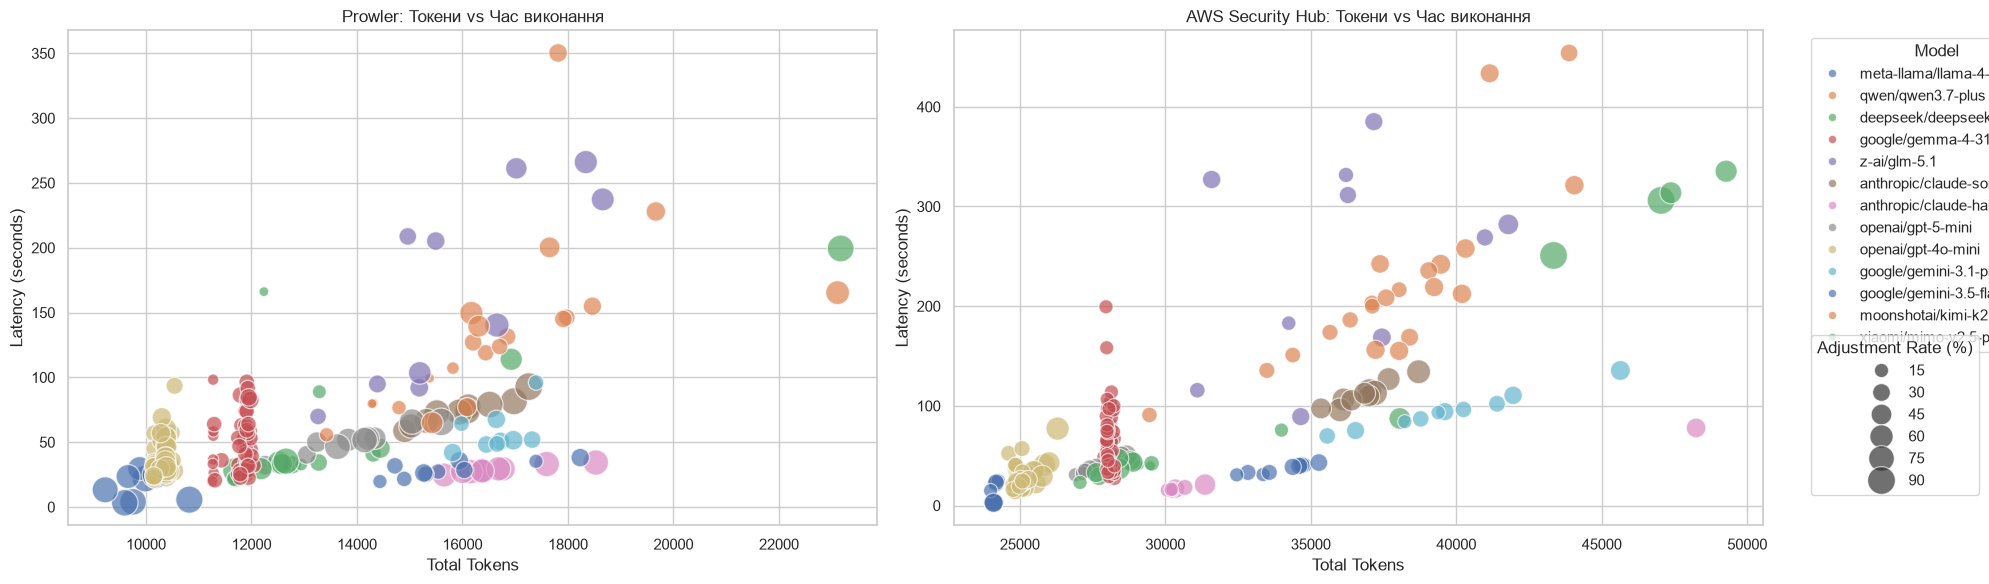

In [6]:
if not metrics_df.empty:
    fig, (ax_p, ax_s) = plt.subplots(1, 2, figsize=(20, 6))
    
    p_df = p_m.copy()
    p_df['total_tokens'] = p_df['prompt_tokens'] + p_df['completion_tokens']
    s_df = s_m.copy()
    s_df['total_tokens'] = s_df['prompt_tokens'] + s_df['completion_tokens']
    
    if not p_df.empty:
        sns.scatterplot(data=p_df, x='total_tokens', y='latency_seconds', hue='model', size='adjustment_rate_percentage', sizes=(50, 400), alpha=0.7, palette='deep', ax=ax_p, legend=False)
        ax_p.set_title("Prowler: Токени vs Час виконання")
        ax_p.set_xlabel("Total Tokens")
        ax_p.set_ylabel("Latency (seconds)")
        
    if not s_df.empty:
        sns.scatterplot(data=s_df, x='total_tokens', y='latency_seconds', hue='model', size='adjustment_rate_percentage', sizes=(50, 400), alpha=0.7, palette='deep', ax=ax_s)
        ax_s.set_title("AWS Security Hub: Токени vs Час виконання")
        ax_s.set_xlabel("Total Tokens")
        ax_s.set_ylabel("Latency (seconds)")
        
        # Split legends
        h, l = ax_s.get_legend_handles_labels()
        if h:
            try:
                # Seaborn adds the column names as titles in the legend labels list
                split_idx = l.index('adjustment_rate_percentage')
                
                # Model legend
                l1, h1 = l[1:split_idx], h[1:split_idx]  # skip the 'model' title string at index 0
                leg1 = ax_s.legend(h1, l1, title="Model", bbox_to_anchor=(1.05, 1), loc='upper left')
                ax_s.add_artist(leg1)
                
                # Adjustment Rate legend
                l2, h2 = l[split_idx+1:], h[split_idx+1:]
                leg2 = ax_s.legend(h2, l2, title="Adjustment Rate (%)", bbox_to_anchor=(1.05, 0.4), loc='upper left')
            except ValueError:
                # Fallback if names differ
                ax_s.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    fig.tight_layout()
    plt.show()

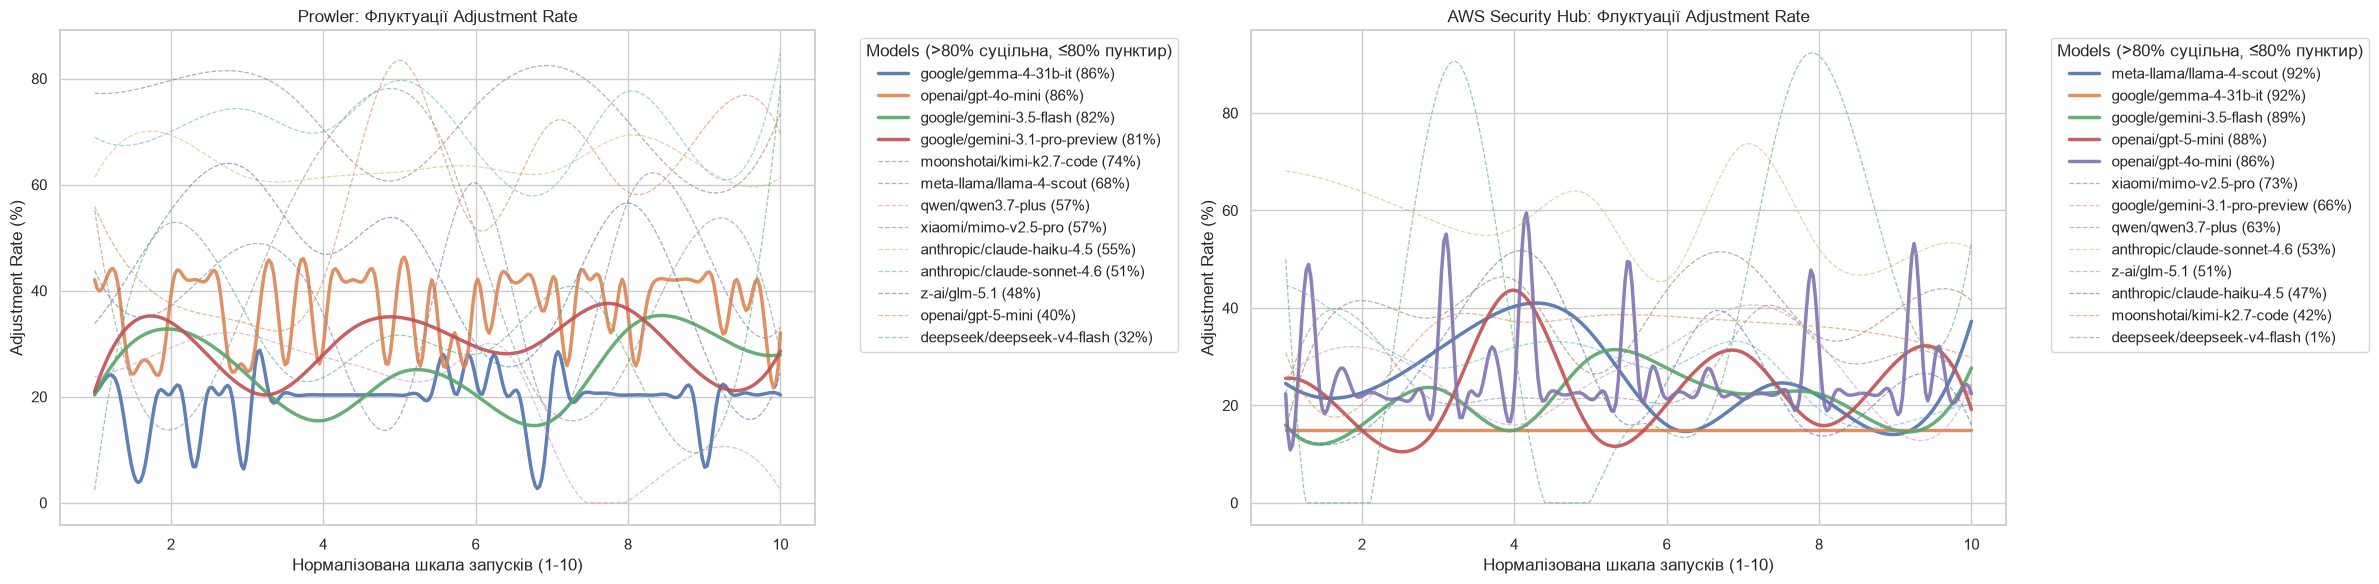

In [7]:
import numpy as np
from scipy.interpolate import make_interp_spline

if not metrics_df.empty:
    fig, (ax_p, ax_s) = plt.subplots(1, 2, figsize=(24, 6))
    
    p_cons_map = {}
    if not p_df.empty and not findings_df.empty:
        for model in p_df["model"].unique():
            mod_f = findings_df[(findings_df["model"] == model) & (findings_df["cspm_tool"] == "prowler")]
            if not mod_f.empty:
                mod_f = mod_f.copy()
                mod_f["decision"] = mod_f["adjusted_severity"].astype(str) + "_" + mod_f["is_false_positive"].astype(str) + "_" + mod_f["adjustment_category"].astype(str)
                cons_df = mod_f.groupby(["finding_id", "resource_id"])["decision"].nunique()
                p_cons_map[model] = (cons_df == 1).mean() * 100
                
    s_cons_map = {}
    if not s_df.empty and not findings_df.empty:
        for model in s_df["model"].unique():
            mod_f = findings_df[(findings_df["model"] == model) & (findings_df["cspm_tool"] == "securityhub")]
            if not mod_f.empty:
                mod_f = mod_f.copy()
                mod_f["decision"] = mod_f["adjusted_severity"].astype(str) + "_" + mod_f["is_false_positive"].astype(str) + "_" + mod_f["adjustment_category"].astype(str)
                cons_df = mod_f.groupby(["finding_id", "resource_id"])["decision"].nunique()
                s_cons_map[model] = (cons_df == 1).mean() * 100

    def plot_smooth(ax, m_data, model, cons, ls, lw, alp):
        x_vals = np.linspace(1, 10, len(m_data))
        y_vals = m_data["adjustment_rate_percentage"].values
        if len(x_vals) >= 4:
            spline = make_interp_spline(x_vals, y_vals, k=3)
            x_smooth = np.linspace(x_vals.min(), x_vals.max(), 300)
            y_smooth = np.clip(spline(x_smooth), 0, 100)
        else:
            x_smooth = x_vals
            y_smooth = y_vals
        ax.plot(x_smooth, y_smooth, label=f"{model} ({cons:.0f}%)", linewidth=lw, linestyle=ls, alpha=alp)

    if not p_df.empty:
        p_df = p_df.sort_values("timestamp")
        sorted_models_p = sorted(p_df["model"].unique(), key=lambda m: p_cons_map.get(m, 0), reverse=True)
        for model in sorted_models_p:
            m_data = p_df[p_df["model"] == model]
            cons = p_cons_map.get(model, 0)
            ls = "-" if cons > 80 else "--"
            lw = 2.5 if cons > 80 else 0.9
            alp = 0.9 if cons > 80 else 0.6
            plot_smooth(ax_p, m_data, model, cons, ls, lw, alp)
        
        ax_p.set_title("Prowler: Флуктуації Adjustment Rate")
        ax_p.set_xlabel("Нормалізована шкала запусків (1-10)")
        ax_p.set_ylabel("Adjustment Rate (%)")
        ax_p.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Models (>80% суцільна, ≤80% пунктир)")
        
    if not s_df.empty:
        s_df = s_df.sort_values("timestamp")
        sorted_models_s = sorted(s_df["model"].unique(), key=lambda m: s_cons_map.get(m, 0), reverse=True)
        for model in sorted_models_s:
            m_data = s_df[s_df["model"] == model]
            cons = s_cons_map.get(model, 0)
            ls = "-" if cons > 80 else "--"
            lw = 2.5 if cons > 80 else 0.9
            alp = 0.9 if cons > 80 else 0.6
            plot_smooth(ax_s, m_data, model, cons, ls, lw, alp)
            
        ax_s.set_title("AWS Security Hub: Флуктуації Adjustment Rate")
        ax_s.set_xlabel("Нормалізована шкала запусків (1-10)")
        ax_s.set_ylabel("Adjustment Rate (%)")
        ax_s.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Models (>80% суцільна, ≤80% пунктир)")

    fig.tight_layout()
    plt.show()


In [8]:
if not metrics_df.empty:
    final_export = calculate_summary(metrics_df, findings_df)
    final_export